In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,roc_curve
from sklearn import svm
from sklearn.svm import SVC

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/mushroom_cleaned.csv')

In [4]:
df.head(5)

,cap-diameter,cap-shape,gill-attachment,gill-color,stem-height,stem-width,stem-color,season,class
0,1372,2,2,10,3.807467,1545,11,1.804273,1
1,1461,2,2,10,3.807467,1557,11,1.804273,1
2,1371,2,2,10,3.612496,1566,11,1.804273,1
3,1261,6,2,10,3.787572,1566,11,1.804273,1
4,1305,6,2,10,3.711971,1464,11,0.943195,1


In [5]:
df.shape

(54035, 9)

In [6]:
df.drop_duplicates(inplace = True)

In [7]:
 df.describe()

,cap-diameter,cap-shape,gill-attachment,gill-color,stem-height,stem-width,stem-color,season,class
count,53732.000000,53732.000000,53732.000000,53732.000000,53732.000000,53732.000000,53732.000000,53732.000000,53732.000000
mean,568.629178,4.005900,2.142857,7.344599,0.752102,1057.000633,8.454013,0.952322,0.546639
std,360.384461,2.165188,2.232546,3.190447,0.645987,780.263033,3.235507,0.303795,0.497825
min,0.000000,0.000000,0.000000,0.000000,0.000426,0.000000,0.000000,0.027372,0.000000
25%,290.000000,2.000000,0.000000,5.000000,0.270146,430.000000,6.000000,0.888450,0.000000
50%,528.000000,5.000000,1.000000,8.000000,0.589316,929.000000,11.000000,0.943195,1.000000
75%,782.000000,6.000000,4.000000,10.000000,1.046900,1527.000000,11.000000,0.943195,1.000000
max,1891.000000,6.000000,6.000000,11.000000,3.835320,3569.000000,12.000000,1.804273,1.000000


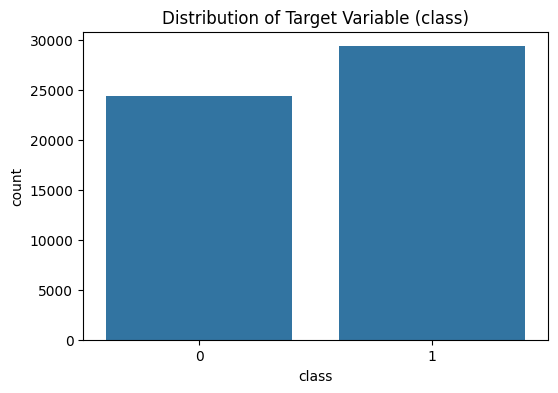

In [8]:
plt.figure(figsize = (6,4))
sns.countplot(x = df['class'],data = df)
plt.title('Distribution of Target Variable (class)')
plt.show()

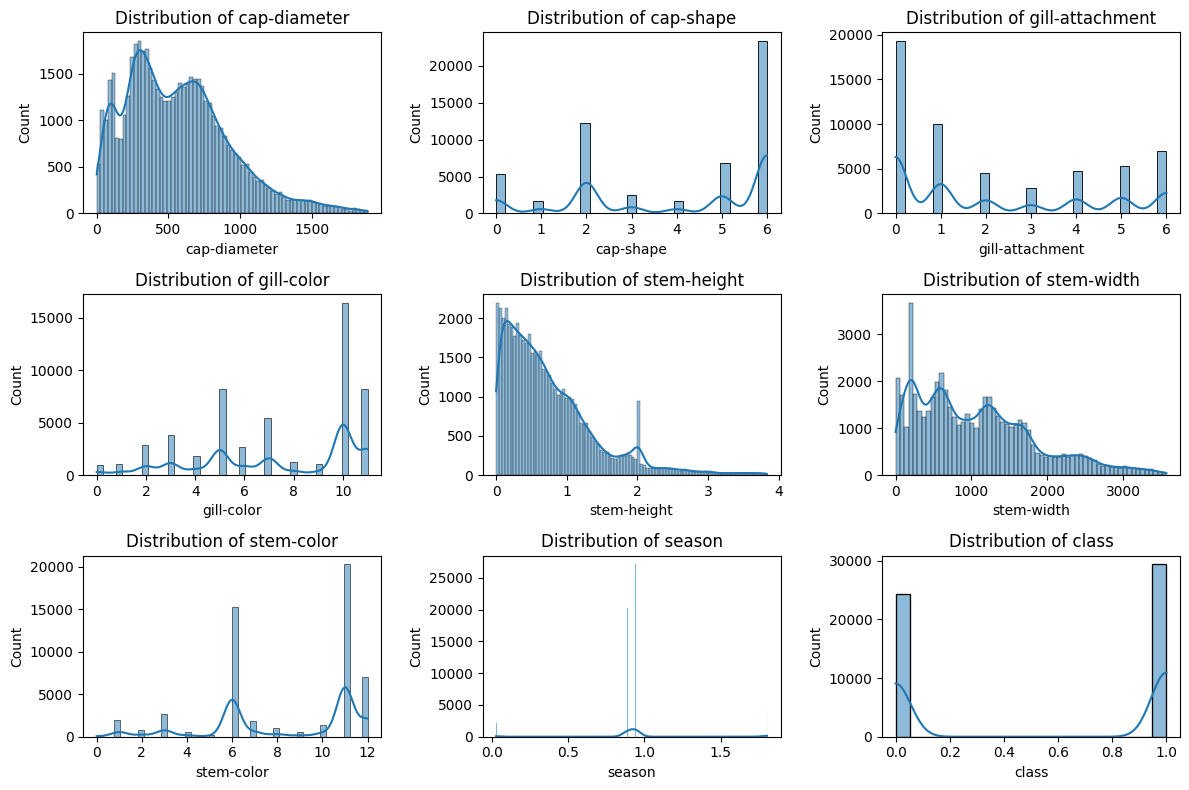

In [9]:
plt.figure(figsize = (12,8))
for i,col in enumerate(df.columns):
  if df[col].dtype != 'object':
    plt.subplot(3,3,i+1)
    sns.histplot(df[col],kde = True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

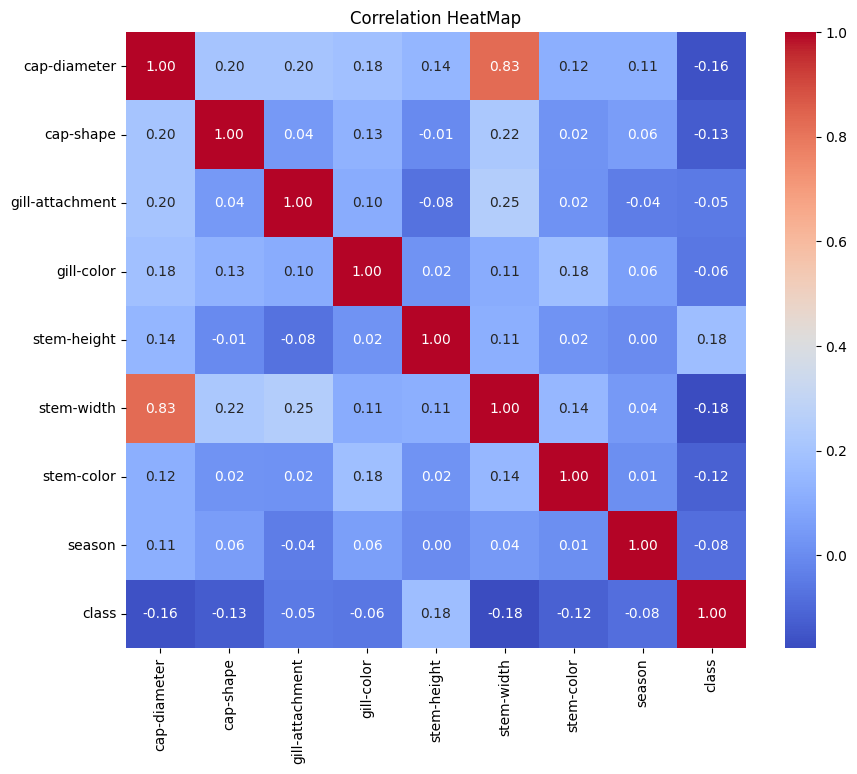

In [10]:
numeric_cols = df.select_dtypes(include =  np.number).columns
correlation_matrix = df[numeric_cols].corr()
plt.figure(figsize = (10,8))
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm',fmt = '.2f')
plt.title('Correlation HeatMap')
plt.show()

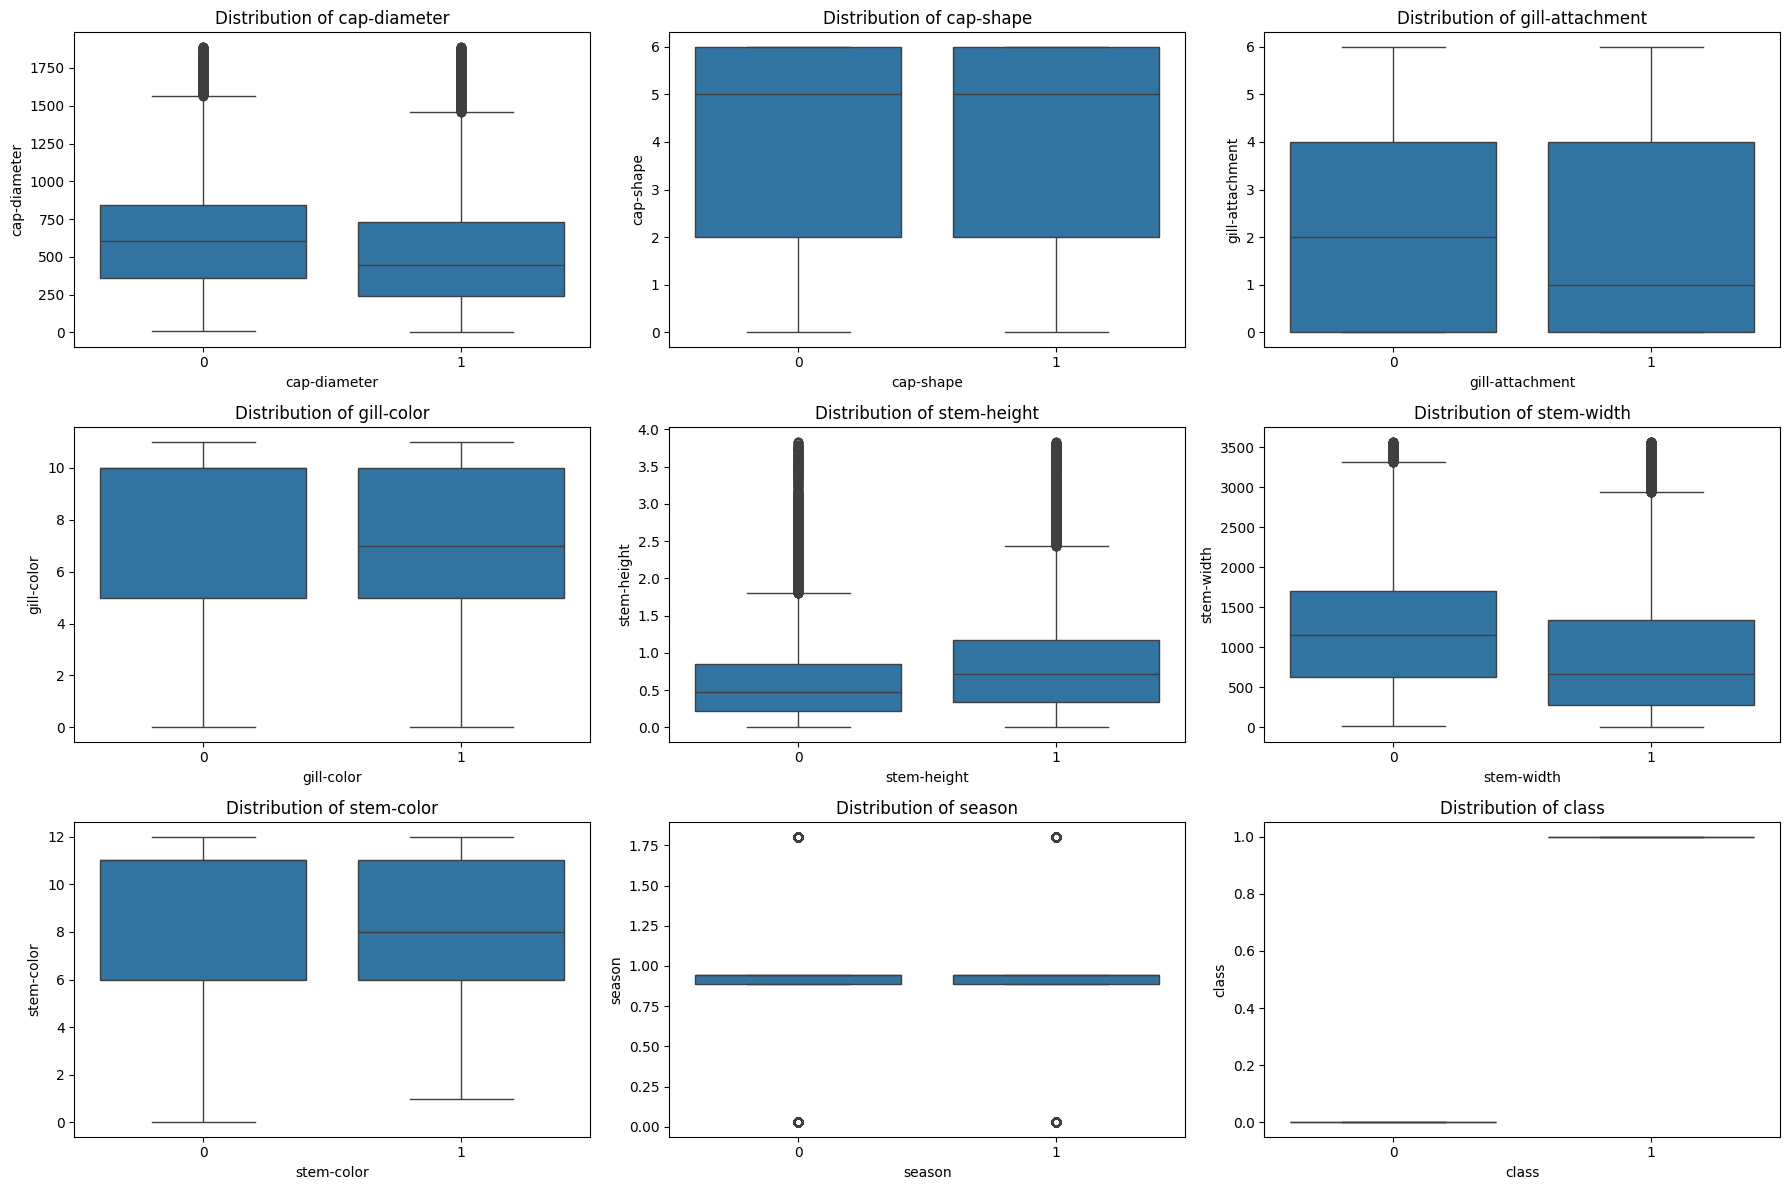

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for idx, col in enumerate(df.columns):
    sns.boxplot(data=df, x='class', y=col, ax=axes[idx])
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
for i in range(len(df.columns), len(axes)):
    fig.delaxes(axes[i])
plt.tight_layout()
plt.show()

In [12]:
X = df.drop('class',axis = 1)
Y = df['class']

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size = 0.2,random_state = 42)

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
kernels = ['linear','poly','rbf','sigmoid']
results = {}

for _,kernel in enumerate(kernels):
    model = SVC(kernel = kernel,random_state = 42,probability = True)
    model.fit(X_train,y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test,y_pred)
    report = classification_report(y_test,y_pred)
    matrix = confusion_matrix(y_test,y_pred)

    y_pred_proba = model.predict_proba(X_test)[:,1]
    fpr,tpr,thresholds = roc_curve(y_test,y_pred_proba)
    roc_auc = roc_auc_score(y_test,y_pred_proba)

    results[kernel] = {
        'accuracy':accuracy,
        'classification_report':report,
        'confusion_matrix':matrix,
        'fpr':fpr,
        'tpr':tpr,
        'roc_auc':roc_auc
    }

In [16]:
print("Summary of results of all kernels:\n")
for kernel,metrics in results.items():
    print(f"\nKernel:{kernel}")
    print(f"\nAccuracy:{metrics['accuracy']}")
    print(f"Classification Report:\n{metrics['classification_report']}")
    print(f"Confusion Matrix:\n{metrics['confusion_matrix']}")

Summary of results of all kernels:


Kernel:linear

Accuracy:0.6295710430817902
Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.56      0.57      4783
           1       0.66      0.69      0.67      5964

    accuracy                           0.63     10747
   macro avg       0.62      0.62      0.62     10747
weighted avg       0.63      0.63      0.63     10747

Confusion Matrix:
[[2657 2126]
 [1855 4109]]

Kernel:poly

Accuracy:0.7606773983437238
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.72      0.73      4783
           1       0.78      0.80      0.79      5964

    accuracy                           0.76     10747
   macro avg       0.76      0.76      0.76     10747
weighted avg       0.76      0.76      0.76     10747

Confusion Matrix:
[[3432 1351]
 [1221 4743]]

Kernel:rbf

Accuracy:0.9058341862845445
Classification Report:
              precision 

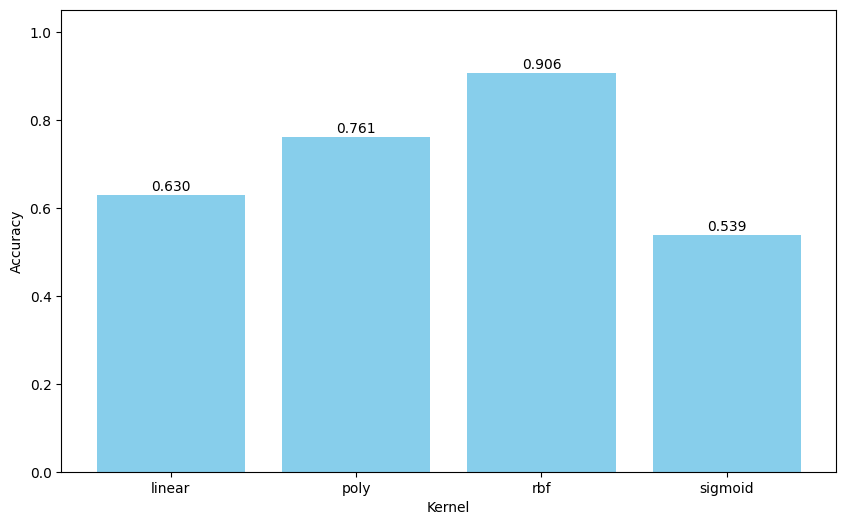

In [17]:
kernel_names = list(results.keys())
accuracies = [results[kernel]['accuracy']for kernel in kernel_names]

plt.figure(figsize = (10,6))
plt.bar(kernel_names,accuracies,color = 'skyblue')
plt.xlabel('Kernel')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.01, f'{acc:.3f}', ha='center')
plt.show()

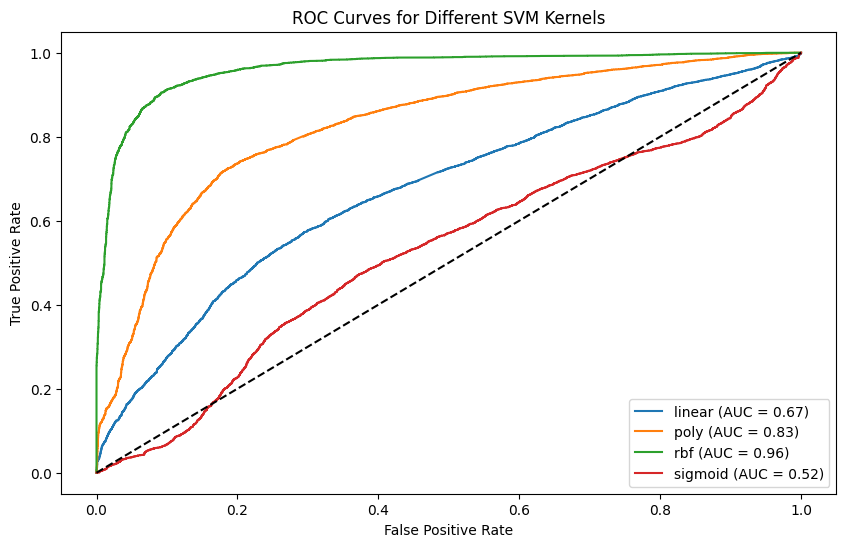

In [18]:
plt.figure(figsize=(10, 6))
for kernel, metrics in results.items():
    plt.plot(metrics['fpr'], metrics['tpr'], label=f'{kernel} (AUC = {metrics["roc_auc"]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Different SVM Kernels')
plt.legend(loc='lower right')
plt.show()